# Results

In [1]:
DATASET_PATH = "../dataset/bigcodebench_normalized_filtered.json"
OUT_PATH      = "../results/bigcodebench_llm_clones.json"
OLLAMA_MODEL = "llama3.1:latest"   

# Generation settings
LLM_OPTS = {
    "temperature": 0.1,
    "top_p": 0.95,
    "repeat_penalty": 1.05,
    "num_predict": 768,   
}

N_ENTRIES = 4
CLONES_PER_ENTRY = 2  

## Running tests

In [2]:
import json
from src.utils import install_package, extract_required_packages
with open(OUT_PATH, "r", encoding="utf-8") as f:
    clone_data = json.load(f)  # dataset with clones
packages = extract_required_packages(clone_data)
print(f"Requried packages: {packages}")
for pkg in packages:
    try:
        __import__(pkg)
    except ImportError:
        try:
            print(f"Installing missing package: {pkg}")
            install_package(pkg)
        except Exception as e:
            print(f"⚠️ Could not install package {pkg}, skipping. Reason: {e}")

Requried packages: set()


In [3]:
import json 
import re
from src.utils import validate_with_unittest

with open(DATASET_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)  # original dataset with tests
with open(OUT_PATH, "r", encoding="utf-8") as f:
    clone_data = json.load(f)  # dataset with clones

data_by_id = {entry["id"]: entry for entry in data}

for i, clone_entry in enumerate(clone_data, 1):
    entry_id = clone_entry["id"]
    print(f"\nTesting Entry {i}/{len(clone_data)} | id={entry_id}")

    if entry_id not in data_by_id:
        print(f"  ⚠️ No matching entry found for {entry_id}, skipping.")
        continue

    entry = data_by_id[entry_id]
    tests_list = entry.get("test", [])

    for k, clone in enumerate(clone_entry.get("clones", []), 1):
        try:
            # Skip when it was already tested 
            if "test_results" in clone and clone["test_results"]:
                print(f"  Clone {k}: already has test results, skipping.")
                continue

            code = clone["code"]
            test_results = validate_with_unittest(code, tests_list)
            clone["test_results"] = test_results

            passed = sum(1 for v in test_results.values() if v == "PASS")
            failed = sum(1 for v in test_results.values() if v == "FAIL")
            error = sum(1 for v in test_results.values() if v.startswith("ERROR"))
            total = len(test_results)
            print(f"  Clone {k}: PASS={passed}, FAIL={failed}, ERROR={error}, Total={total}")

        except Exception as e:
            print(f"  ❌ Unexpected error testing clone {k}: {e}")
            error_results = {}
            for test_code in tests_list:
                match = re.search(r'def (\w+)\(', test_code)
                test_name = match.group(1) if match else f"unknown_test_{len(error_results)+1}"
                error_results[test_name] = "ERROR"
            clone["test_results"] = error_results
 
        with open(OUT_PATH, "w", encoding="utf-8") as f:
            json.dump(clone_data, f, indent=2)

print(f"\n✅ Done. Saved dataset with test results to {OUT_PATH}")



Testing Entry 1/6 | id=BigCodeBench/0
  Clone 1: already has test results, skipping.
  Clone 2: already has test results, skipping.
  Clone 3: already has test results, skipping.
  Clone 4: already has test results, skipping.
  Clone 5: already has test results, skipping.
  Clone 6: already has test results, skipping.
  Clone 7: already has test results, skipping.
  Clone 8: already has test results, skipping.
  Clone 9: already has test results, skipping.
  Clone 10: already has test results, skipping.
  Clone 11: already has test results, skipping.
  Clone 12: already has test results, skipping.
  Clone 13: already has test results, skipping.
  Clone 14: already has test results, skipping.
  Clone 15: already has test results, skipping.
  Clone 16: already has test results, skipping.
  Clone 17: already has test results, skipping.
  Clone 18: already has test results, skipping.
  Clone 19: already has test results, skipping.
  Clone 20: already has test results, skipping.
  Clone 21

## Calculating similarity scores

In [4]:
import json
import numpy as np
from codebleu import calc_codebleu

# CONFIG
K = 500

# Load dataset
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)  # original dataset with tests
with open(OUT_PATH, "r", encoding="utf-8") as f:
    clone_data = json.load(f)  # dataset with clones

data_by_id = {entry["id"]: entry for entry in data}

# Iterate like in the test script
for i, clone_entry in enumerate(clone_data, 1):
    entry_id = clone_entry["id"]
    print(f"\nEvaluating Entry {i}/{len(clone_data)} | id={entry_id}")

    if entry_id not in data_by_id:
        print(f"  ⚠️ No matching entry found for {entry_id}, skipping.")
        continue

    entry = data_by_id[entry_id]
    ref = entry.get("original_code", None)
    if not ref:
        print("  ⚠️ No reference code found, skipping.")
        continue

    for k, clone in enumerate(clone_entry.get("clones", []), 1):
        try:
            # Skip if already computed
            if "metrics" in clone and "codebleu" in clone["metrics"]:
                print(f"  Clone {k}: already has CodeBLEU, skipping.")
                continue

            hyp = clone["code"]
            codebleu_score = calc_codebleu([ref], [hyp], lang="python")

            clone.setdefault("metrics", {})
            clone["metrics"].update({
                "codebleu": float(codebleu_score["codebleu"]),
                "ngram_match_score": float(codebleu_score["ngram_match_score"]),
                "weighted_ngram_match_score": float(codebleu_score["weighted_ngram_match_score"]),
                "syntax_match_score": float(codebleu_score["syntax_match_score"]),
                "dataflow_match_score": float(codebleu_score["dataflow_match_score"]),
            })

            print(f"  Clone {k}: CodeBLEU={clone['metrics']['codebleu']:.4f}")

        except Exception as e:
            print(f"  ❌ Error computing CodeBLEU for clone {k}: {e}")

        # Save progress after each clone (safer)
        with open(OUT_PATH, "w", encoding="utf-8") as f:
            json.dump(clone_data, f, indent=2)

print(f"\n✅ Done. Saved dataset with CodeBLEU scores to {OUT_PATH}")



Evaluating Entry 1/6 | id=BigCodeBench/0
  Clone 1: already has CodeBLEU, skipping.
  Clone 2: already has CodeBLEU, skipping.
  Clone 3: already has CodeBLEU, skipping.
  Clone 4: already has CodeBLEU, skipping.
  Clone 5: already has CodeBLEU, skipping.
  Clone 6: already has CodeBLEU, skipping.
  Clone 7: already has CodeBLEU, skipping.
  Clone 8: already has CodeBLEU, skipping.
  Clone 9: already has CodeBLEU, skipping.
  Clone 10: already has CodeBLEU, skipping.
  Clone 11: already has CodeBLEU, skipping.
  Clone 12: already has CodeBLEU, skipping.
  Clone 13: already has CodeBLEU, skipping.
  Clone 14: already has CodeBLEU, skipping.
  Clone 15: already has CodeBLEU, skipping.
  Clone 16: already has CodeBLEU, skipping.
  Clone 17: already has CodeBLEU, skipping.
  Clone 18: already has CodeBLEU, skipping.
  Clone 19: already has CodeBLEU, skipping.
  Clone 20: already has CodeBLEU, skipping.
  Clone 21: already has CodeBLEU, skipping.
  Clone 22: already has CodeBLEU, skipping.

In [5]:
# import json
# from collections import Counter
# from nltk.util import ngrams
# import numpy as np
# from crystalbleu import corpus_bleu
# from codebleu import calc_codebleu
# from nltk.translate.bleu_score import SmoothingFunction
# from src.similarity import tokenize_code, is_trivial_ngram
# import fractions

# #  CONFIG 
# K = 500
# sm_func = SmoothingFunction(epsilon=0.0001).method1

# #  Patch Fraction for Python >=3.11 
# _OrigFraction_new = fractions.Fraction.__new__
# def fraction_new_patched(cls, *args, **kwargs):
#     kwargs.pop("_normalize", None)
#     return _OrigFraction_new(cls, *args, **kwargs)
# fractions.Fraction.__new__ = fraction_new_patched

# #  Load dataset 
# with open(OUT_PATH, "r", encoding="utf-8") as f:
#     dataset = json.load(f)

# #  Build global ngram frequency 
# all_ngrams = []
# for entry in dataset:
#     tokens = tokenize_code(entry["original_code"])
#     for n in range(1,5):
#         all_ngrams.extend(list(ngrams(tokens, n)))
#     for clone in entry.get("clones", []):
#         tokens = tokenize_code(clone["code"])
#         for n in range(1,5):
#             all_ngrams.extend(list(ngrams(tokens, n)))

# freq = Counter(all_ngrams)
# most_common_dict = {ngram:1 for ngram,_ in freq.most_common(K) if not is_trivial_ngram(ngram)}

# #  Compute BLEU / CrystalBLEU / CodeBLEU 
# labels, bleu_scores, crystal_scores, codebleu_scores = [], [], [], []

# for entry in dataset:
#     ref = tokenize_code(entry["original_code"])
#     for clone in entry.get("clones", []):
#         hyp = tokenize_code(clone["code"])
#         labels.append(1)

#         bleu = corpus_bleu([ref], [hyp], smoothing_function=sm_func)
#         crystal = corpus_bleu([ref], [hyp], smoothing_function=sm_func, ignoring=most_common_dict)
#         codebleu_score = calc_codebleu([entry["original_code"]], [clone["code"]], lang="python")["codebleu"]

#         bleu_scores.append(bleu)
#         crystal_scores.append(crystal)
#         codebleu_scores.append(codebleu_score)

#         clone.setdefault("metrics", {})
#         clone["metrics"].update({
#             "bleu": float(bleu),
#             "crystalbleu": float(crystal),
#             "codebleu": float(codebleu_score),
#         })

# #  Compute averages 
# print(f"Avg BLEU: {np.mean(bleu_scores):.4f}")
# print(f"Avg CrystalBLEU: {np.mean(crystal_scores):.4f}")
# print(f"Avg CodeBLEU: {np.mean(codebleu_scores):.4f}")

# #  Save dataset 
# with open(OUT_PATH, "w", encoding="utf-8") as f:
#     json.dump(dataset, f, indent=2)

# #  Restore original Fraction to avoid side effects 
# fractions.Fraction.__new__ = _OrigFraction_new

# print("✅ Finished scoring with BLEU, CrystalBLEU, and CodeBLEU.")


## Plotting

### Overall

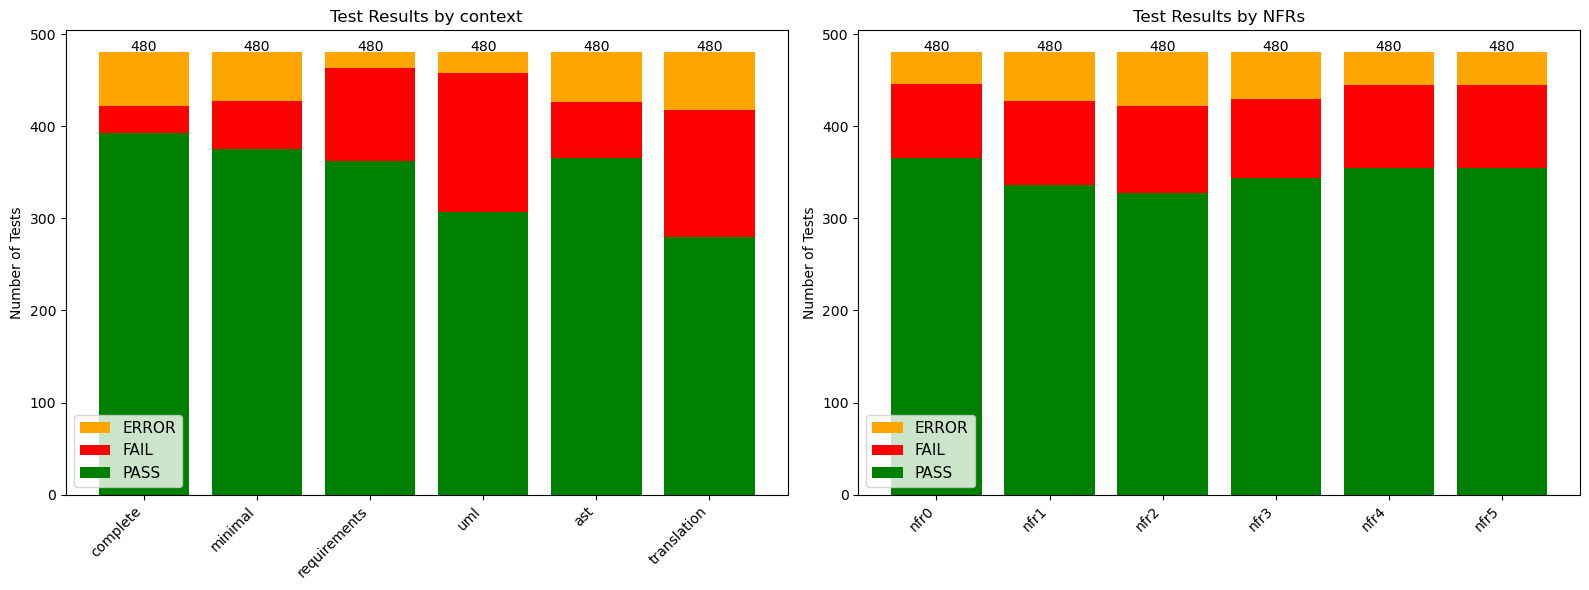

In [6]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Initialize dictionaries for grouping
grouped_by_context = {}
grouped_by_nfrs = {}

for entry in dataset:
    # Determine expected number of tests for this entry
    if entry.get("clones"):
        num_tests = max(len(clone.get("test_results", {})) for clone in entry["clones"])
    else:
        num_tests = 0

    for clone in entry.get("clones", []):
        context = clone.get("context", "unknown")
        nfrs = clone.get("nfrs", "unknown")
        results = clone.get("test_results", {})

        # Fill missing tests as ERROR
        if len(results) < num_tests:
            missing = num_tests - len(results)
            for i in range(missing):
                results[f"missing_test_{i+1}"] = "ERROR"

        # --- Group by context ---
        if context not in grouped_by_context:
            grouped_by_context[context] = {"PASS": 0, "FAIL": 0, "ERROR": 0}
        for status in results.values():
            status = status.upper()
            if status in ["PASS", "FAIL", "ERROR"]:
                grouped_by_context[context][status] += 1

        # --- Group by NFR ---
        if nfrs not in grouped_by_nfrs:
            grouped_by_nfrs[nfrs] = {"PASS": 0, "FAIL": 0, "ERROR": 0}
        for status in results.values():
            status = status.upper()
            if status in ["PASS", "FAIL", "ERROR"]:
                grouped_by_nfrs[nfrs][status] += 1

# Function to prepare data for plotting
def prepare_data(grouped_dict):
    filters = list(grouped_dict.keys())
    passes = [grouped_dict[h]["PASS"] for h in filters]
    fails  = [grouped_dict[h]["FAIL"] for h in filters]
    errors = [grouped_dict[h]["ERROR"] for h in filters]
    return filters, passes, fails, errors

# Prepare data
filters_context, passes_context, fails_context, errors_context = prepare_data(grouped_by_context)
filters_nfrs, passes_nfrs, fails_nfrs, errors_nfrs = prepare_data(grouped_by_nfrs)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot context ---
x_context = range(len(filters_context))
axes[0].bar(x_context, passes_context, color="green", label="PASS")
axes[0].bar(x_context, fails_context, bottom=passes_context, color="red", label="FAIL")
axes[0].bar(x_context, errors_context, bottom=[p+f for p, f in zip(passes_context, fails_context)], color="orange", label="ERROR")
axes[0].set_xticks(x_context)
axes[0].set_xticklabels(filters_context, rotation=45, ha="right")
axes[0].set_ylabel("Number of Tests")
axes[0].set_title("Test Results by context")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left") 
for i, (p, f, e) in enumerate(zip(passes_context, fails_context, errors_context)):
    total = p + f + e
    axes[0].text(i, total + 2, str(total), ha="center", fontsize=10)

# --- Plot NFRs ---
x_nfrs = range(len(filters_nfrs))
axes[1].bar(x_nfrs, passes_nfrs, color="green", label="PASS")
axes[1].bar(x_nfrs, fails_nfrs, bottom=passes_nfrs, color="red", label="FAIL")
axes[1].bar(x_nfrs, errors_nfrs, bottom=[p+f for p, f in zip(passes_nfrs, fails_nfrs)], color="orange", label="ERROR")
axes[1].set_xticks(x_nfrs)
axes[1].set_xticklabels(filters_nfrs, rotation=45, ha="right")
axes[1].set_ylabel("Number of Tests")
axes[1].set_title("Test Results by NFRs")
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left") 
for i, (p, f, e) in enumerate(zip(passes_nfrs, fails_nfrs, errors_nfrs)):
    total = p + f + e
    axes[1].text(i, total + 2, str(total), ha="center", fontsize=10)

plt.tight_layout()
plt.show()


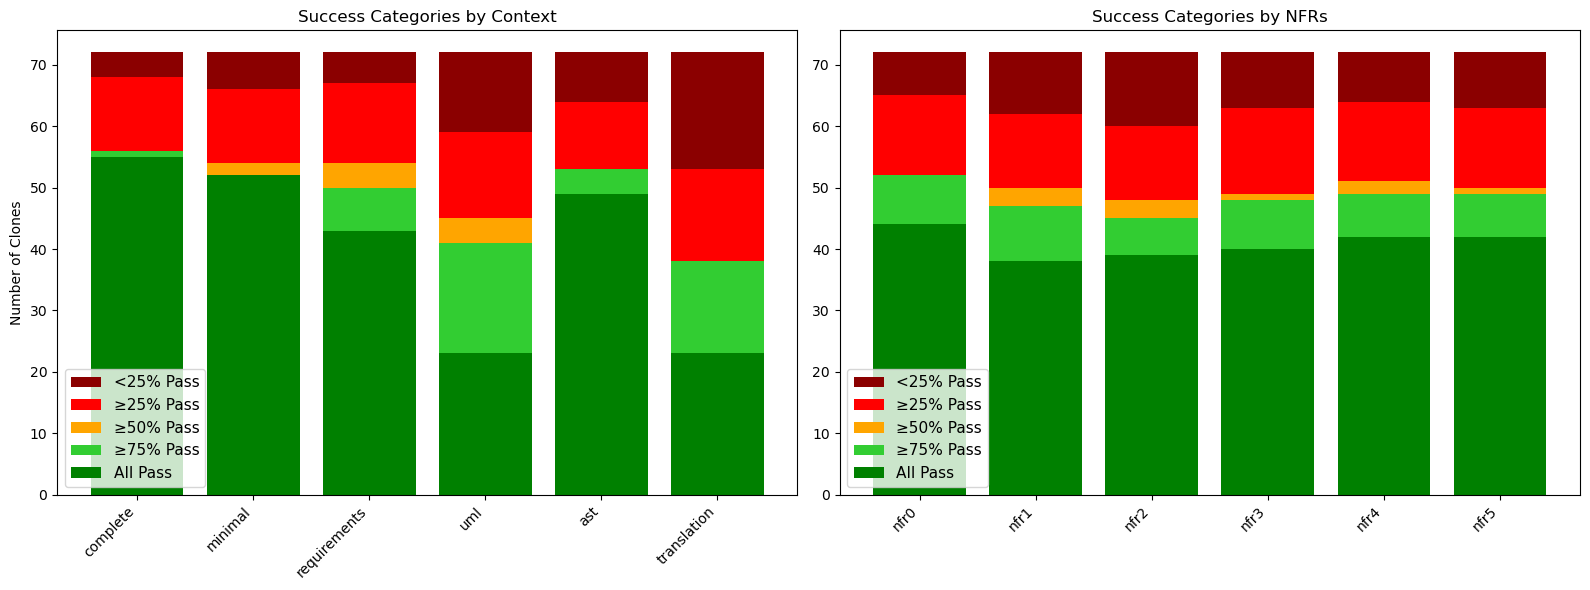

In [7]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)


categories = ["All Pass", "≥75% Pass", "≥50% Pass", "≥25% Pass", "<25% Pass"]

def classify_clone(results, num_tests):
    num_pass = sum(1 for v in results.values() if v.upper() == "PASS")
    ratio = num_pass / num_tests if num_tests > 0 else 0

    if ratio == 1.0:
        return "All Pass"
    elif ratio >= 0.75:
        return "≥75% Pass"
    elif ratio >= 0.50:
        return "≥50% Pass"
    elif ratio >= 0.25:
        return "≥25% Pass"
    else:
        return "<25% Pass"

# Initialize grouping
grouped_context = {}
grouped_nfrs = {}

for entry in dataset:
    if entry.get("clones"):
        num_tests = max(len(clone.get("test_results", {})) for clone in entry["clones"])
    else:
        num_tests = 0

    for clone in entry.get("clones", []):
        context = clone.get("context", "unknown")
        nfrs = clone.get("nfrs", "unknown")
        results = clone.get("test_results", {})

        if len(results) < num_tests:
            for i in range(num_tests - len(results)):
                results[f"missing_test_{i+1}"] = "ERROR"

        category = classify_clone(results, num_tests)

        if context not in grouped_context:
            grouped_context[context] = {c: 0 for c in categories}
        grouped_context[context][category] += 1

        if nfrs not in grouped_nfrs:
            grouped_nfrs[nfrs] = {c: 0 for c in categories}
        grouped_nfrs[nfrs][category] += 1

def plot_grouped(ax, grouped_dict, title):
    filters = list(grouped_dict.keys())
    x = range(len(filters))

    bottoms = [0] * len(filters)
    for cat, color in zip(categories,
                          ["green", "limegreen", "orange", "red", "darkred"]):
        values = [grouped_dict[f][cat] for f in filters]
        ax.bar(x, values, bottom=bottoms, label=cat, color=color)
        bottoms = [b + v for b, v in zip(bottoms, values)]

    ax.set_xticks(x)
    ax.set_xticklabels(filters, rotation=45, ha="right", fontsize=10)
    ax.set_title(title)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left") 
    

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_grouped(axes[0], grouped_context, "Success Categories by Context")
plot_grouped(axes[1], grouped_nfrs, "Success Categories by NFRs")
axes[0].set_ylabel("Number of Clones")

plt.tight_layout()
plt.show()


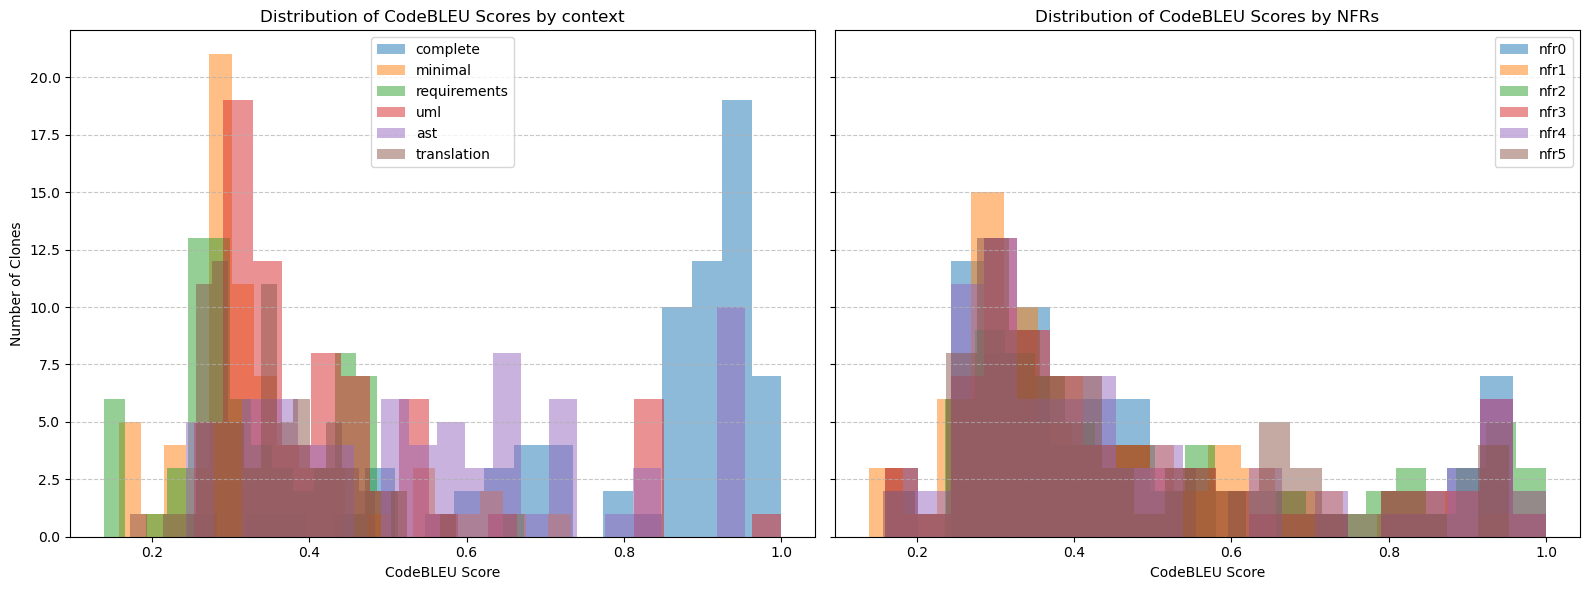

C:\Users\Leticia\AppData\Local\Temp\ipykernel_6520\1468630457.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\Leticia\AppData\Local\Temp\ipykernel_6520\1468630457.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


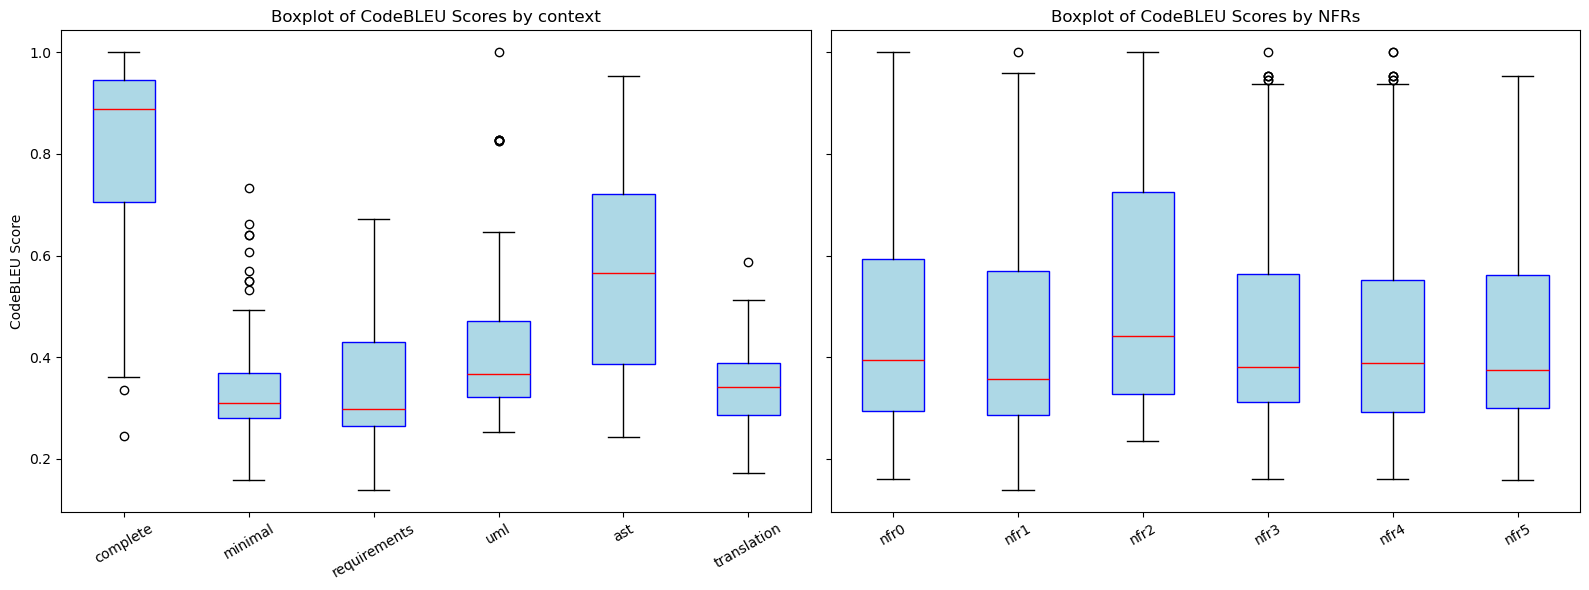

In [8]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

#  Collect CodeBLEU scores per context and per nfrs 
scores_by_context = {}
scores_by_nfrs = {}

for entry in dataset:
    for clone in entry.get("clones", []):
        context = clone.get("context", "unknown")
        nfrs = clone.get("nfrs", "unknown")  # assuming clone has "nfrs" field
        score = clone.get("metrics", {}).get("codebleu")
        if score is not None:
            scores_by_context.setdefault(context, []).append(score)
            scores_by_nfrs.setdefault(nfrs, []).append(score)

#  Histograms side by side 
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Histogram by context
for context, scores in scores_by_context.items():
    axes[0].hist(scores, bins=20, alpha=0.5, label=context)
axes[0].set_xlabel("CodeBLEU Score")
axes[0].set_ylabel("Number of Clones")
axes[0].set_title("Distribution of CodeBLEU Scores by context")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Histogram by NFRs
for nfrs, scores in scores_by_nfrs.items():
    axes[1].hist(scores, bins=20, alpha=0.5, label=nfrs)
axes[1].set_xlabel("CodeBLEU Score")
axes[1].set_title("Distribution of CodeBLEU Scores by NFRs")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

#  Boxplots side by side 
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Boxplot by context
labels_context = list(scores_by_context.keys())
data_context = [scores_by_context[m] for m in labels_context]
axes[0].boxplot(
    data_context, vert=True, patch_artist=True,
    labels=labels_context,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red")
)
axes[0].set_ylabel("CodeBLEU Score")
axes[0].set_title("Boxplot of CodeBLEU Scores by context")
axes[0].tick_params(axis="x", rotation=30)

# Boxplot by NFRs
labels_nfrs = list(scores_by_nfrs.keys())
data_nfrs = [scores_by_nfrs[n] for n in labels_nfrs]
axes[1].boxplot(
    data_nfrs, vert=True, patch_artist=True,
    labels=labels_nfrs,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red")
)
axes[1].set_title("Boxplot of CodeBLEU Scores by NFRs")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

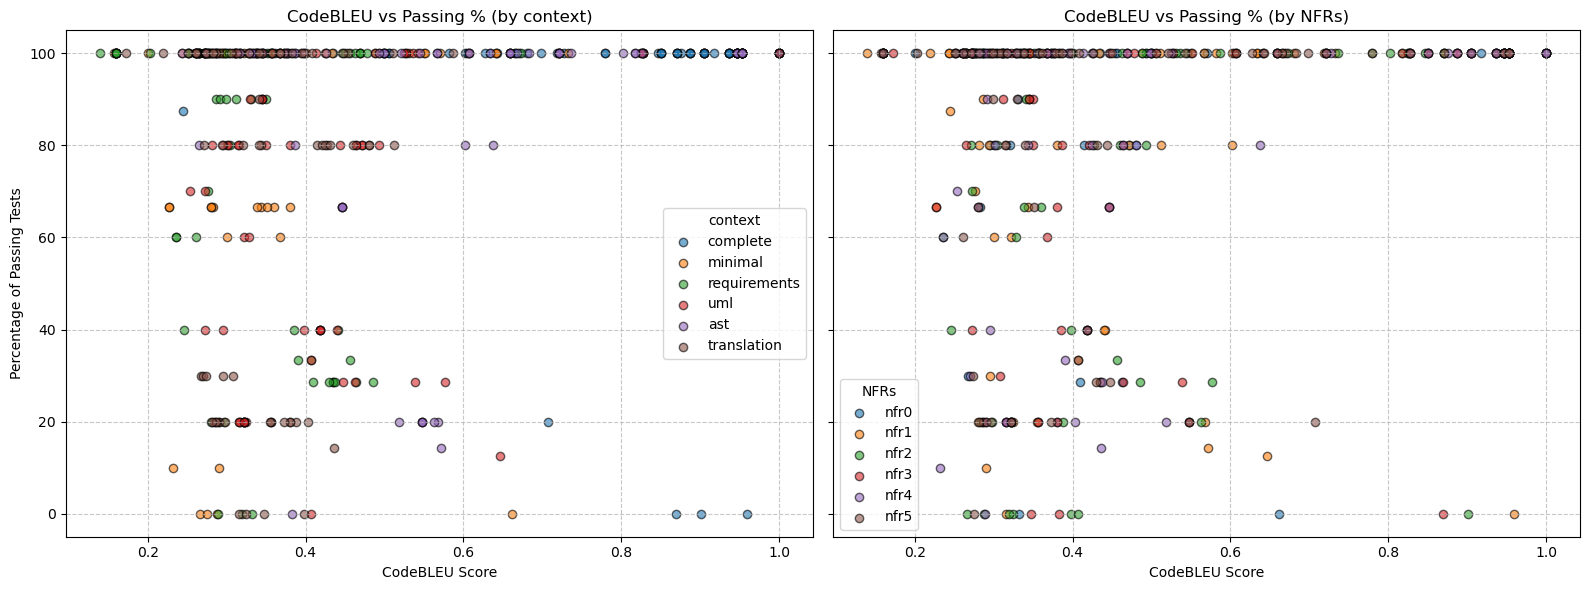

In [9]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

#  Collect per-clone metrics, grouped by context and nfrs 
grouped_by_context = {}
grouped_by_nfrs = {}

for entry in dataset:
    for clone in entry.get("clones", []):
        results = clone.get("test_results", {})
        total_tests = len(results)
        if total_tests == 0:
            continue

        passed_tests = sum(1 for status in results.values() if status.upper() == "PASS")
        passing_percentage = 100 * passed_tests / total_tests
        score = clone.get("metrics", {}).get("codebleu", 0)

        context = clone.get("context", "unknown")
        nfrs = clone.get("nfrs", "unknown")  # assuming clone has "nfrs" field

        # --- group by context ---
        if context not in grouped_by_context:
            grouped_by_context[context] = {"codebleu": [], "passing": []}
        grouped_by_context[context]["codebleu"].append(score)
        grouped_by_context[context]["passing"].append(passing_percentage)

        # --- group by nfrs ---
        if nfrs not in grouped_by_nfrs:
            grouped_by_nfrs[nfrs] = {"codebleu": [], "passing": []}
        grouped_by_nfrs[nfrs]["codebleu"].append(score)
        grouped_by_nfrs[nfrs]["passing"].append(passing_percentage)

#  Scatter plots side by side 
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

# Scatter by context
for context, data in grouped_by_context.items():
    axes[0].scatter(
        data["codebleu"],
        data["passing"],
        alpha=0.6,
        edgecolor="black",
        label=context
    )
axes[0].set_xlabel("CodeBLEU Score")
axes[0].set_ylabel("Percentage of Passing Tests")
axes[0].set_title("CodeBLEU vs Passing % (by context)")
axes[0].legend(title="context")
axes[0].grid(linestyle="--", alpha=0.7)

# Scatter by NFRs
for nfrs, data in grouped_by_nfrs.items():
    axes[1].scatter(
        data["codebleu"],
        data["passing"],
        alpha=0.6,
        edgecolor="black",
        label=nfrs
    )
axes[1].set_xlabel("CodeBLEU Score")
axes[1].set_title("CodeBLEU vs Passing % (by NFRs)")
axes[1].legend(title="NFRs")
axes[1].grid(linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


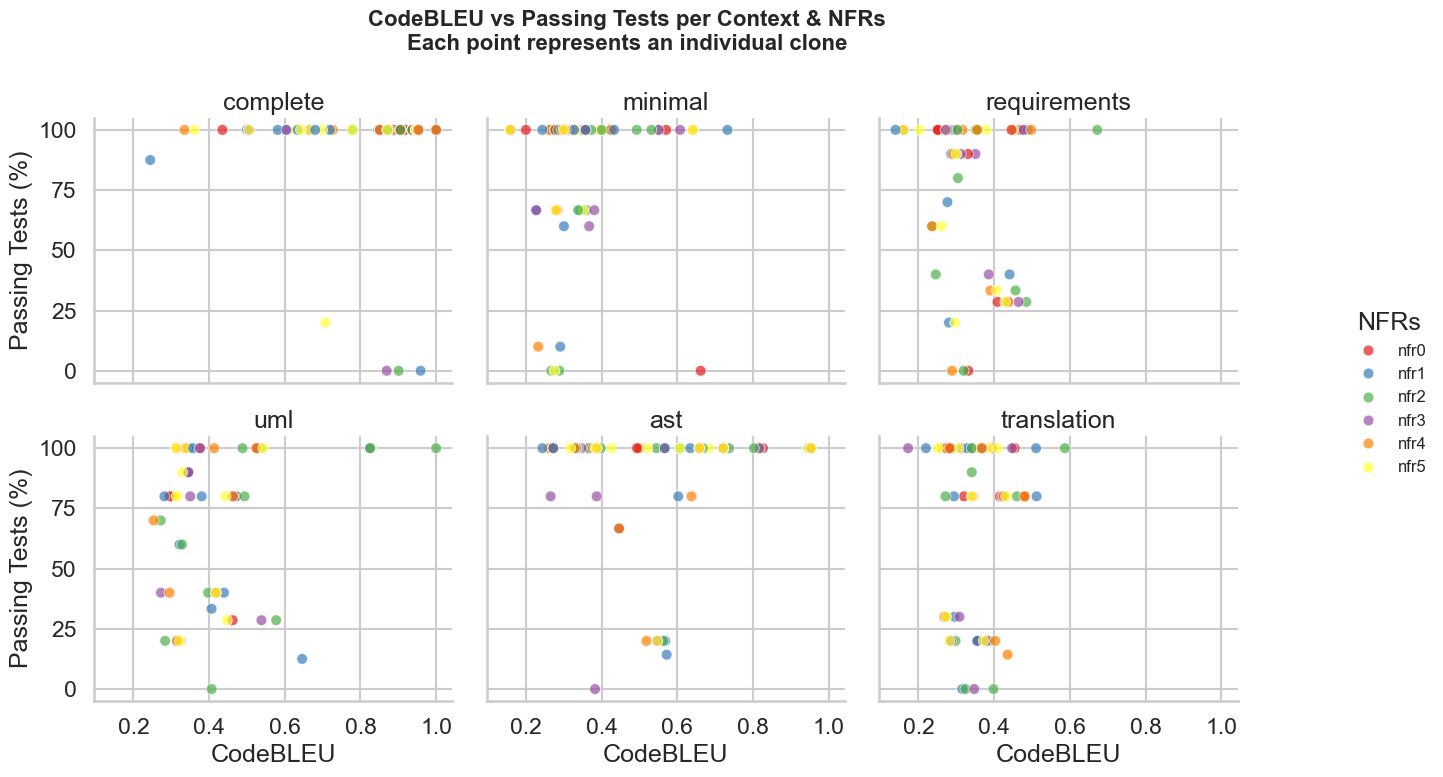

In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load dataset ===
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# === Flatten data ===
records = []
for entry in dataset:
    for clone in entry.get("clones", []):
        results = clone.get("test_results", {})
        total_tests = len(results)
        if total_tests == 0:
            continue
        passed_tests = sum(1 for status in results.values() if status.upper() == "PASS")
        passing_percentage = 100 * passed_tests / total_tests
        score = clone.get("metrics", {}).get("codebleu", 0)

        context = clone.get("context", "unknown")
        nfrs = clone.get("nfrs", "unknown")
        records.append({
            "context": context,
            "nfrs": nfrs,
            "codebleu": score,
            "passing": passing_percentage
        })

df = pd.DataFrame(records)

# === Plotting using FacetGrid ===
sns.set_style("whitegrid")
sns.set_context("talk")

# Each subplot = one context
g = sns.FacetGrid(df, col="context", col_wrap=3, height=4, sharex=True, sharey=True)

# Scatter plot per NFR
g.map_dataframe(
    sns.scatterplot,
    x="codebleu",
    y="passing",
    hue="nfrs",
    palette="Set1",
    alpha=0.7,
    s=60
)

# Axis labels
g.set_axis_labels("CodeBLEU", "Passing Tests (%)")
g.set_titles(col_template="{col_name}")

# Figure title with clarification
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle(
    "CodeBLEU vs Passing Tests per Context & NFRs\nEach point represents an individual clone",
    fontsize=16, weight="bold"
)

# Legend outside
g.add_legend(title="NFRs", bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.show()


### Per LLM

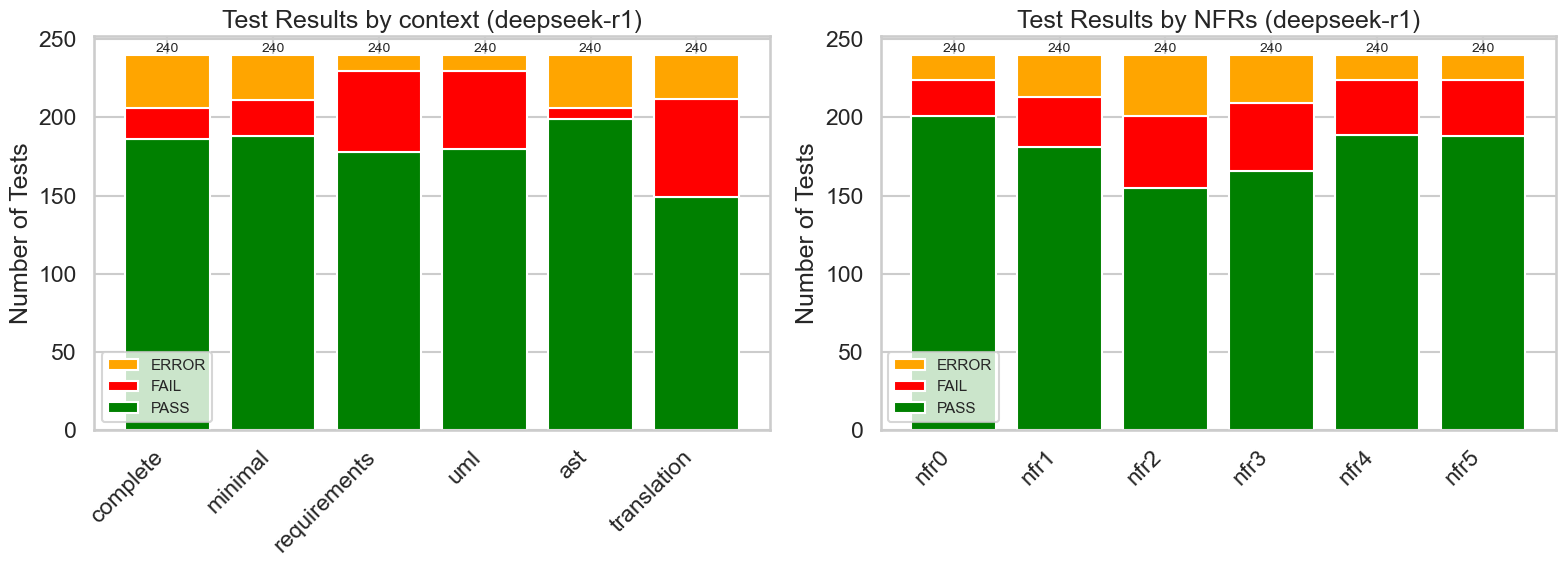

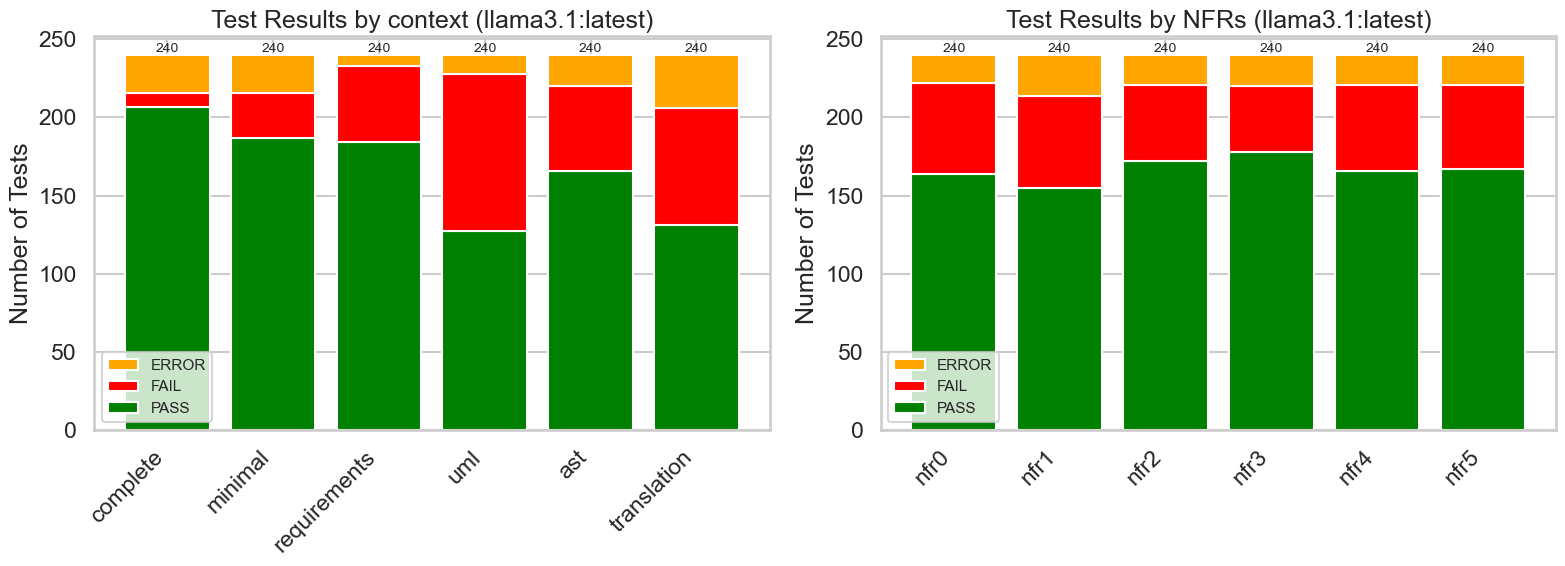

In [11]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Group clones by model
models = set()
for entry in dataset:
    for clone in entry.get("clones", []):
        models.add(clone.get("model", "unknown"))

models = sorted(models)  # consistent order

for model in models:
    grouped_by_context = {}
    grouped_by_nfrs = {}

    for entry in dataset:
        # Determine expected number of tests
        if entry.get("clones"):
            num_tests = max(len(clone.get("test_results", {})) for clone in entry["clones"])
        else:
            num_tests = 0

        for clone in entry.get("clones", []):
            if clone.get("model") != model:
                continue  # skip other models

            context = clone.get("context", "unknown")
            nfrs = clone.get("nfrs", "unknown")
            results = clone.get("test_results", {})

            # Fill missing tests as ERROR
            if len(results) < num_tests:
                missing = num_tests - len(results)
                for i in range(missing):
                    results[f"missing_test_{i+1}"] = "ERROR"

            # --- Group by context ---
            if context not in grouped_by_context:
                grouped_by_context[context] = {"PASS": 0, "FAIL": 0, "ERROR": 0}
            for status in results.values():
                status = status.upper()
                if status in ["PASS", "FAIL", "ERROR"]:
                    grouped_by_context[context][status] += 1

            # --- Group by NFR ---
            if nfrs not in grouped_by_nfrs:
                grouped_by_nfrs[nfrs] = {"PASS": 0, "FAIL": 0, "ERROR": 0}
            for status in results.values():
                status = status.upper()
                if status in ["PASS", "FAIL", "ERROR"]:
                    grouped_by_nfrs[nfrs][status] += 1

    # Function to prepare data for plotting
    def prepare_data(grouped_dict):
        filters = list(grouped_dict.keys())
        passes = [grouped_dict[h]["PASS"] for h in filters]
        fails  = [grouped_dict[h]["FAIL"] for h in filters]
        errors = [grouped_dict[h]["ERROR"] for h in filters]
        return filters, passes, fails, errors

    # Prepare data
    filters_context, passes_context, fails_context, errors_context = prepare_data(grouped_by_context)
    filters_nfrs, passes_nfrs, fails_nfrs, errors_nfrs = prepare_data(grouped_by_nfrs)

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Plot context ---
    x_context = range(len(filters_context))
    axes[0].bar(x_context, passes_context, color="green", label="PASS")
    axes[0].bar(x_context, fails_context, bottom=passes_context, color="red", label="FAIL")
    axes[0].bar(x_context, errors_context, bottom=[p+f for p,f in zip(passes_context, fails_context)], color="orange", label="ERROR")
    axes[0].set_xticks(x_context)
    axes[0].set_xticklabels(filters_context, rotation=45, ha="right")
    axes[0].set_ylabel("Number of Tests")
    axes[0].set_title(f"Test Results by context ({model})")
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left")
    for i, (p,f,e) in enumerate(zip(passes_context, fails_context, errors_context)):
        total = p+f+e
        axes[0].text(i, total+2, str(total), ha="center", fontsize=10)

    # --- Plot NFRs ---
    x_nfrs = range(len(filters_nfrs))
    axes[1].bar(x_nfrs, passes_nfrs, color="green", label="PASS")
    axes[1].bar(x_nfrs, fails_nfrs, bottom=passes_nfrs, color="red", label="FAIL")
    axes[1].bar(x_nfrs, errors_nfrs, bottom=[p+f for p,f in zip(passes_nfrs, fails_nfrs)], color="orange", label="ERROR")
    axes[1].set_xticks(x_nfrs)
    axes[1].set_xticklabels(filters_nfrs, rotation=45, ha="right")
    axes[1].set_ylabel("Number of Tests")
    axes[1].set_title(f"Test Results by NFRs ({model})")
    handles, labels = axes[1].get_legend_handles_labels()
    axes[1].legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left")
    for i, (p,f,e) in enumerate(zip(passes_nfrs, fails_nfrs, errors_nfrs)):
        total = p+f+e
        axes[1].text(i, total+2, str(total), ha="center", fontsize=10)

    plt.tight_layout()
    plt.show()

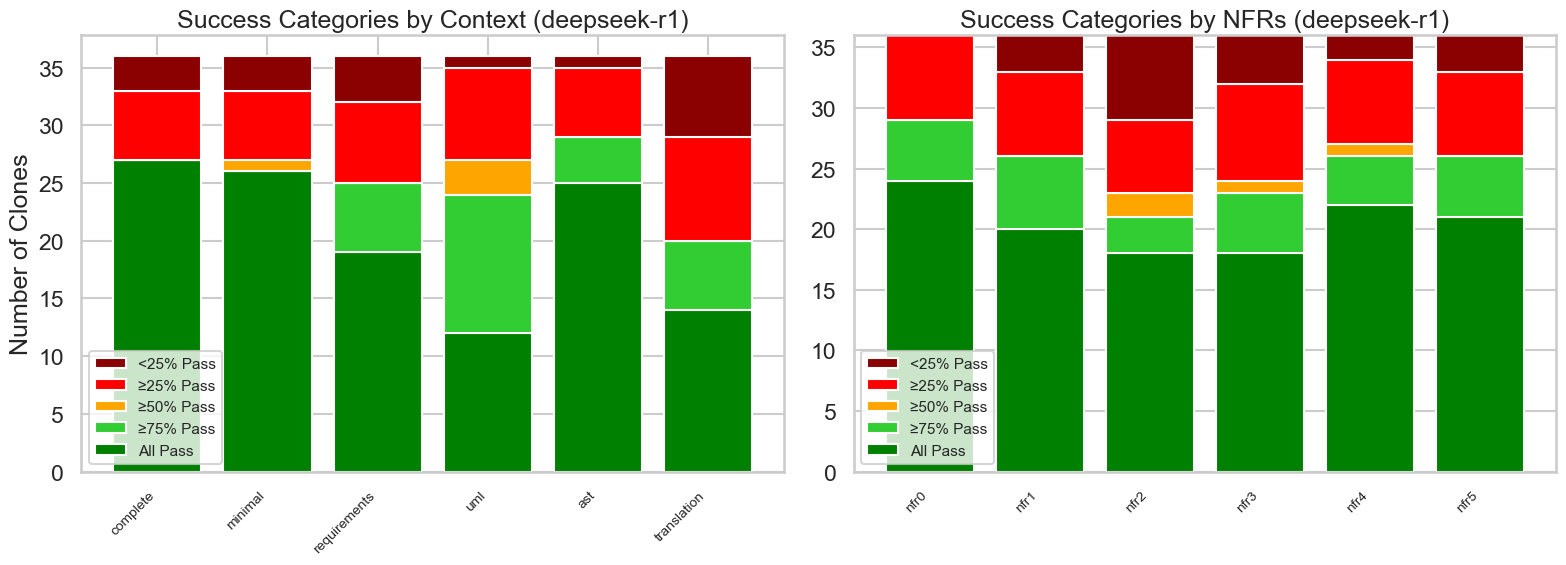

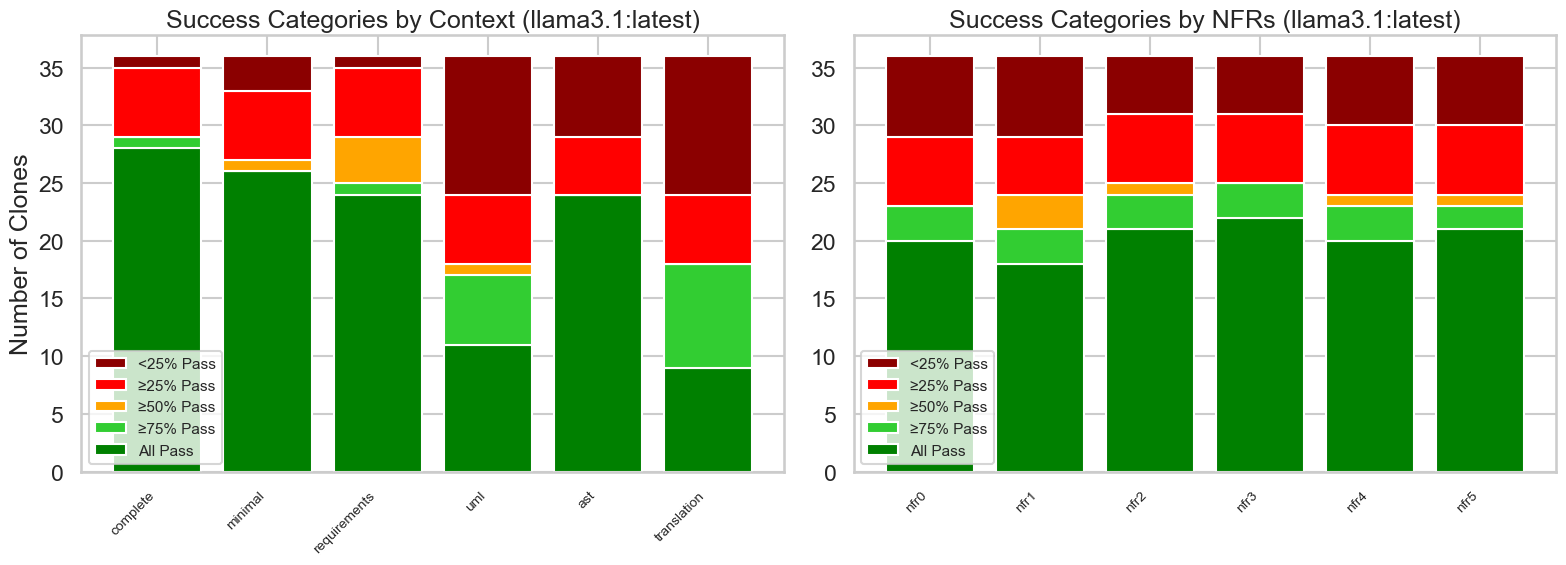

In [12]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)


categories = ["All Pass", "≥75% Pass", "≥50% Pass", "≥25% Pass", "<25% Pass"]
colors = ["green", "limegreen", "orange", "red", "darkred"]

def classify_clone(results, num_tests):
    num_pass = sum(1 for v in results.values() if v.upper() == "PASS")
    ratio = num_pass / num_tests if num_tests > 0 else 0

    if ratio == 1.0:
        return "All Pass"
    elif ratio >= 0.75:
        return "≥75% Pass"
    elif ratio >= 0.50:
        return "≥50% Pass"
    elif ratio >= 0.25:
        return "≥25% Pass"
    else:
        return "<25% Pass"

def plot_grouped(ax, grouped_dict, title):
    filters = list(grouped_dict.keys())
    x = range(len(filters))

    bottoms = [0] * len(filters)
    for cat, color in zip(categories, colors):
        values = [grouped_dict[f][cat] for f in filters]
        ax.bar(x, values, bottom=bottoms, label=cat, color=color)
        bottoms = [b + v for b, v in zip(bottoms, values)]

    ax.set_xticks(x)
    ax.set_xticklabels(filters, rotation=45, ha="right", fontsize=10)
    ax.set_title(title)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], fontsize=11, loc="lower left") 

# --- Detect all models present ---
models = set()
for entry in dataset:
    for clone in entry.get("clones", []):
        models.add(clone.get("model", "unknown"))
models = sorted(models)

# --- One figure per model ---
for model in models:
    grouped_context = {}
    grouped_nfrs = {}

    for entry in dataset:
        if entry.get("clones"):
            num_tests = max(len(clone.get("test_results", {})) for clone in entry["clones"])
        else:
            num_tests = 0

        for clone in entry.get("clones", []):
            if clone.get("model") != model:
                continue  # skip other models

            context = clone.get("context", "unknown")
            nfrs = clone.get("nfrs", "unknown")
            results = clone.get("test_results", {})

            if len(results) < num_tests:
                for i in range(num_tests - len(results)):
                    results[f"missing_test_{i+1}"] = "ERROR"

            category = classify_clone(results, num_tests)

            if context not in grouped_context:
                grouped_context[context] = {c: 0 for c in categories}
            grouped_context[context][category] += 1

            if nfrs not in grouped_nfrs:
                grouped_nfrs[nfrs] = {c: 0 for c in categories}
            grouped_nfrs[nfrs][category] += 1

    # --- Plot for this model ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plot_grouped(axes[0], grouped_context, f"Success Categories by Context ({model})")
    plot_grouped(axes[1], grouped_nfrs, f"Success Categories by NFRs ({model})")
    axes[0].set_ylabel("Number of Clones")

    plt.tight_layout()
    plt.show()


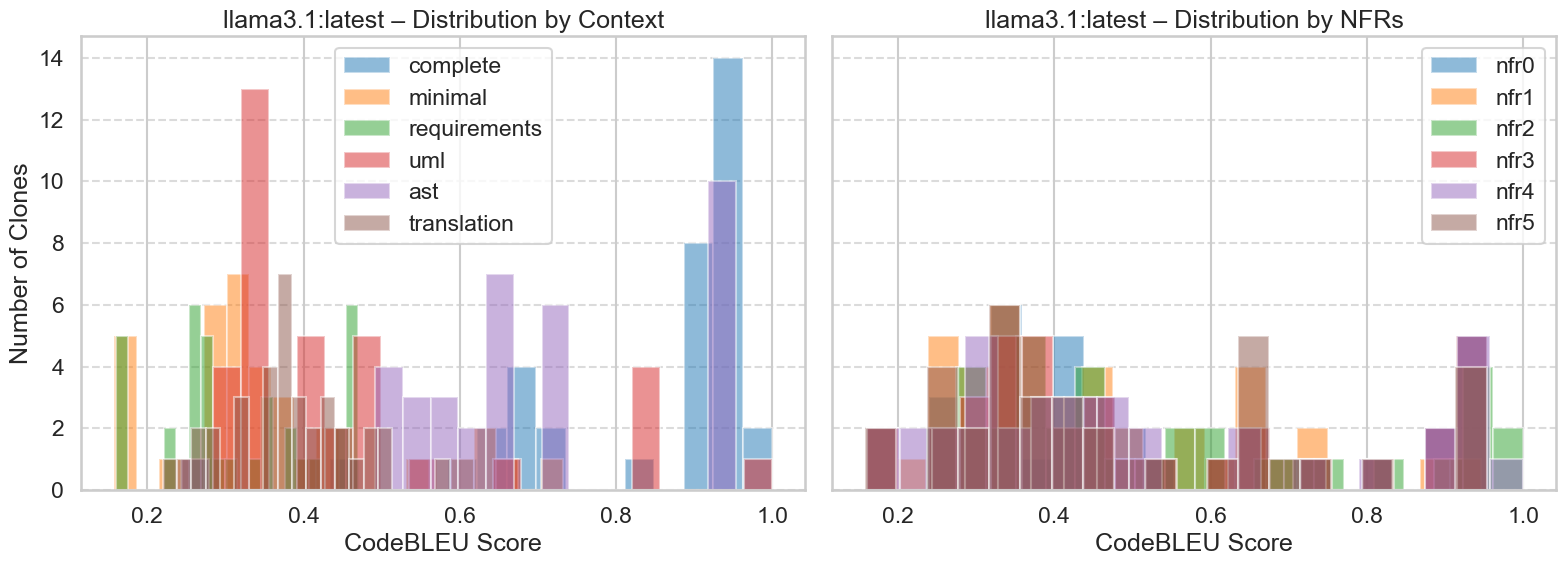

C:\Users\Leticia\AppData\Local\Temp\ipykernel_6520\616599592.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\Leticia\AppData\Local\Temp\ipykernel_6520\616599592.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


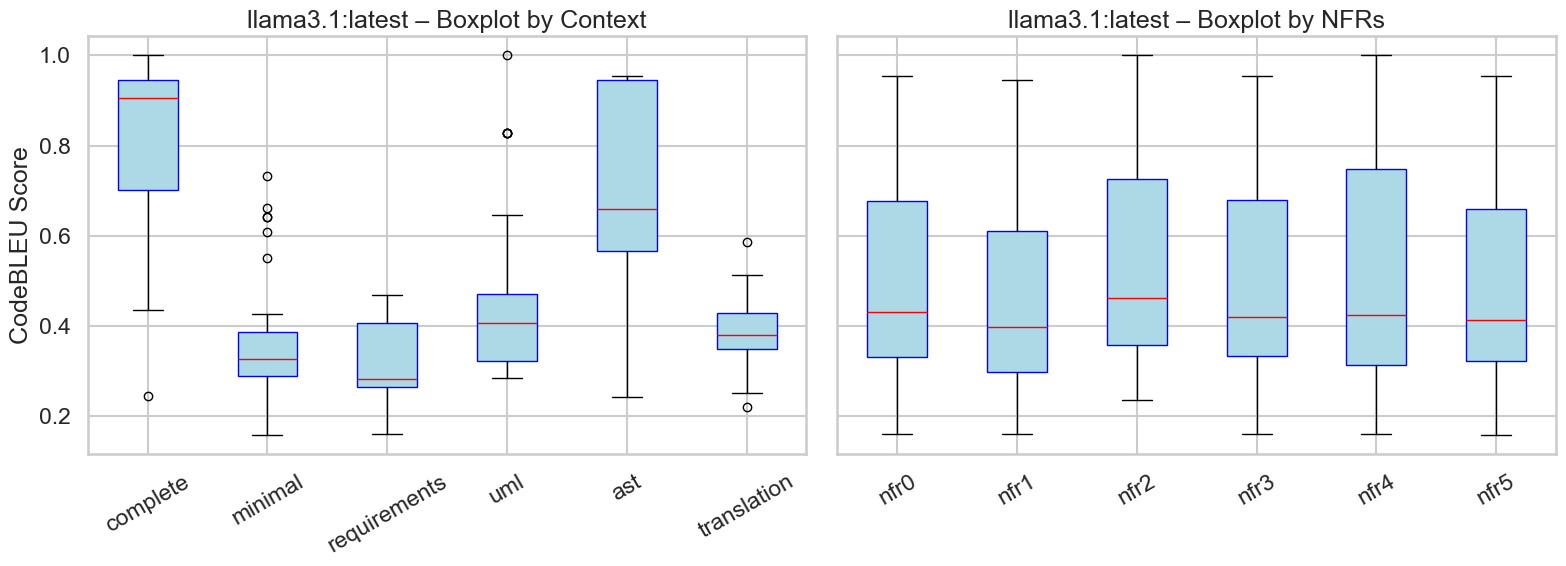

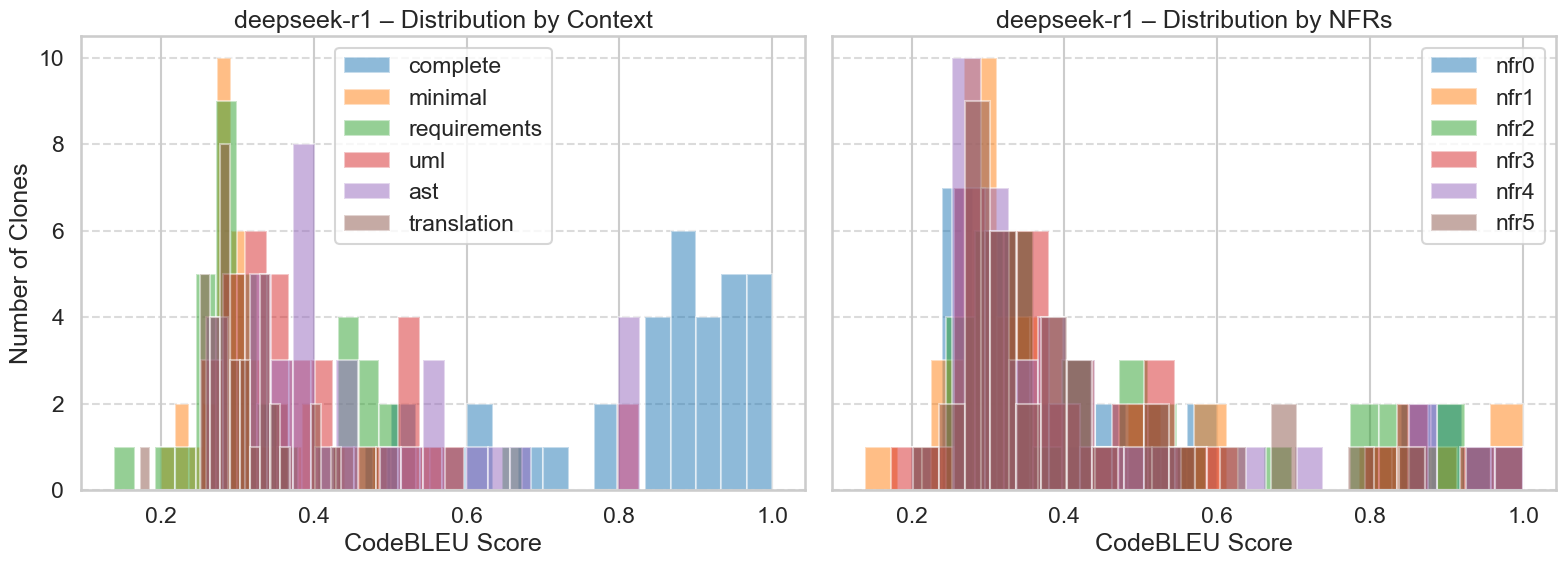

C:\Users\Leticia\AppData\Local\Temp\ipykernel_6520\616599592.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\Leticia\AppData\Local\Temp\ipykernel_6520\616599592.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


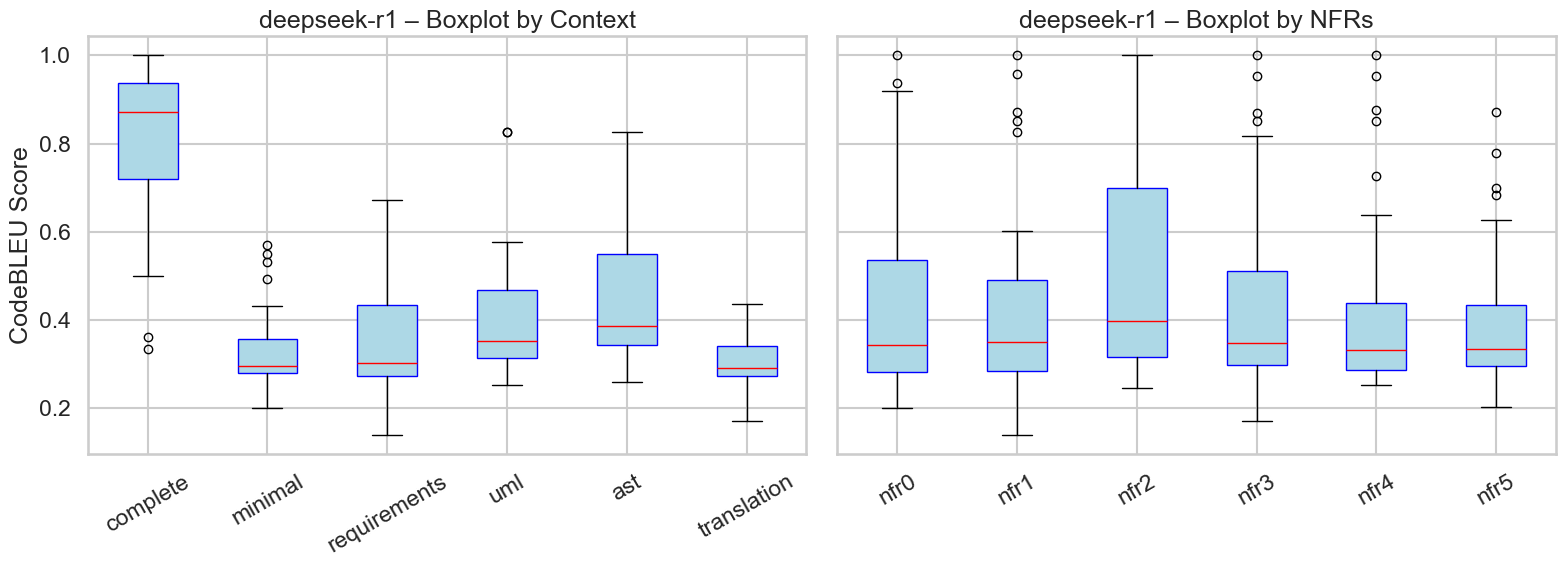

In [13]:
import json
import matplotlib.pyplot as plt

# Load dataset
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# Collect CodeBLEU scores per model → per context/NFR
scores_by_model = {}




for entry in dataset:
    for clone in entry.get("clones", []):
        model = clone.get("model", "unknown")
        context = clone.get("context", "unknown")
        nfrs = clone.get("nfrs", "unknown")
        score = clone.get("metrics", {}).get("codebleu")

        if score is not None:
            model_dict = scores_by_model.setdefault(model, {"context": {}, "nfrs": {}})
            model_dict["context"].setdefault(context, []).append(score)
            model_dict["nfrs"].setdefault(nfrs, []).append(score)

# Generate plots per model
for model, grouped in scores_by_model.items():
    scores_by_context = grouped["context"]
    scores_by_nfrs = grouped["nfrs"]

    # --- Histograms ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for context, scores in scores_by_context.items():
        axes[0].hist(scores, bins=20, alpha=0.5, label=context)
    axes[0].set_xlabel("CodeBLEU Score")
    axes[0].set_ylabel("Number of Clones")
    axes[0].set_title(f"{model} – Distribution by Context")
    axes[0].legend()
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)

    for nfrs, scores in scores_by_nfrs.items():
        axes[1].hist(scores, bins=20, alpha=0.5, label=nfrs)
    axes[1].set_xlabel("CodeBLEU Score")
    axes[1].set_title(f"{model} – Distribution by NFRs")
    axes[1].legend()
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

    # --- Boxplots ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    labels_context = list(scores_by_context.keys())
    data_context = [scores_by_context[c] for c in labels_context]
    axes[0].boxplot(
        data_context, vert=True, patch_artist=True,
        labels=labels_context,
        boxprops=dict(facecolor="lightblue", color="blue"),
        medianprops=dict(color="red")
    )
    axes[0].set_ylabel("CodeBLEU Score")
    axes[0].set_title(f"{model} – Boxplot by Context")
    axes[0].tick_params(axis="x", rotation=30)

    labels_nfrs = list(scores_by_nfrs.keys())
    data_nfrs = [scores_by_nfrs[n] for n in labels_nfrs]
    axes[1].boxplot(
        data_nfrs, vert=True, patch_artist=True,
        labels=labels_nfrs,
        boxprops=dict(facecolor="lightblue", color="blue"),
        medianprops=dict(color="red")
    )
    axes[1].set_title(f"{model} – Boxplot by NFRs")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


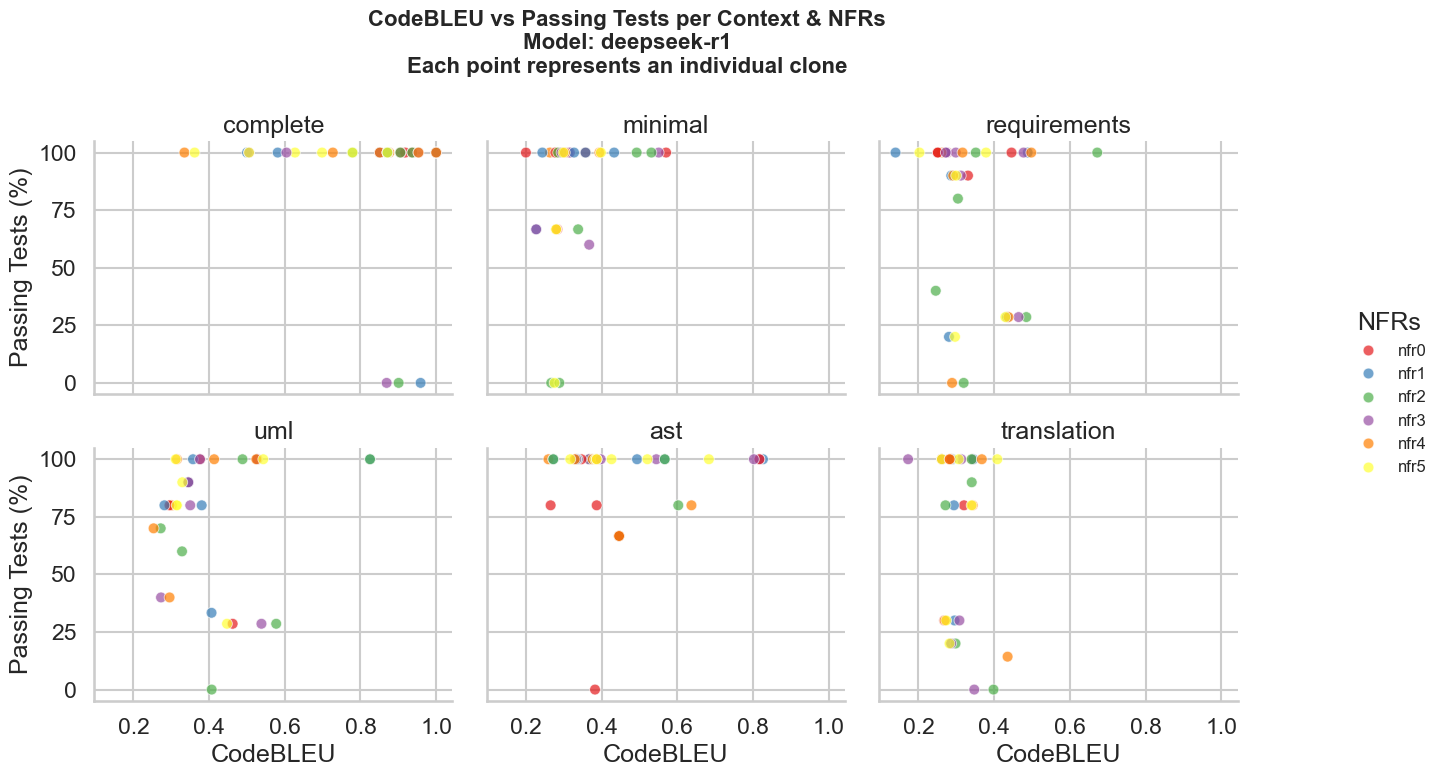

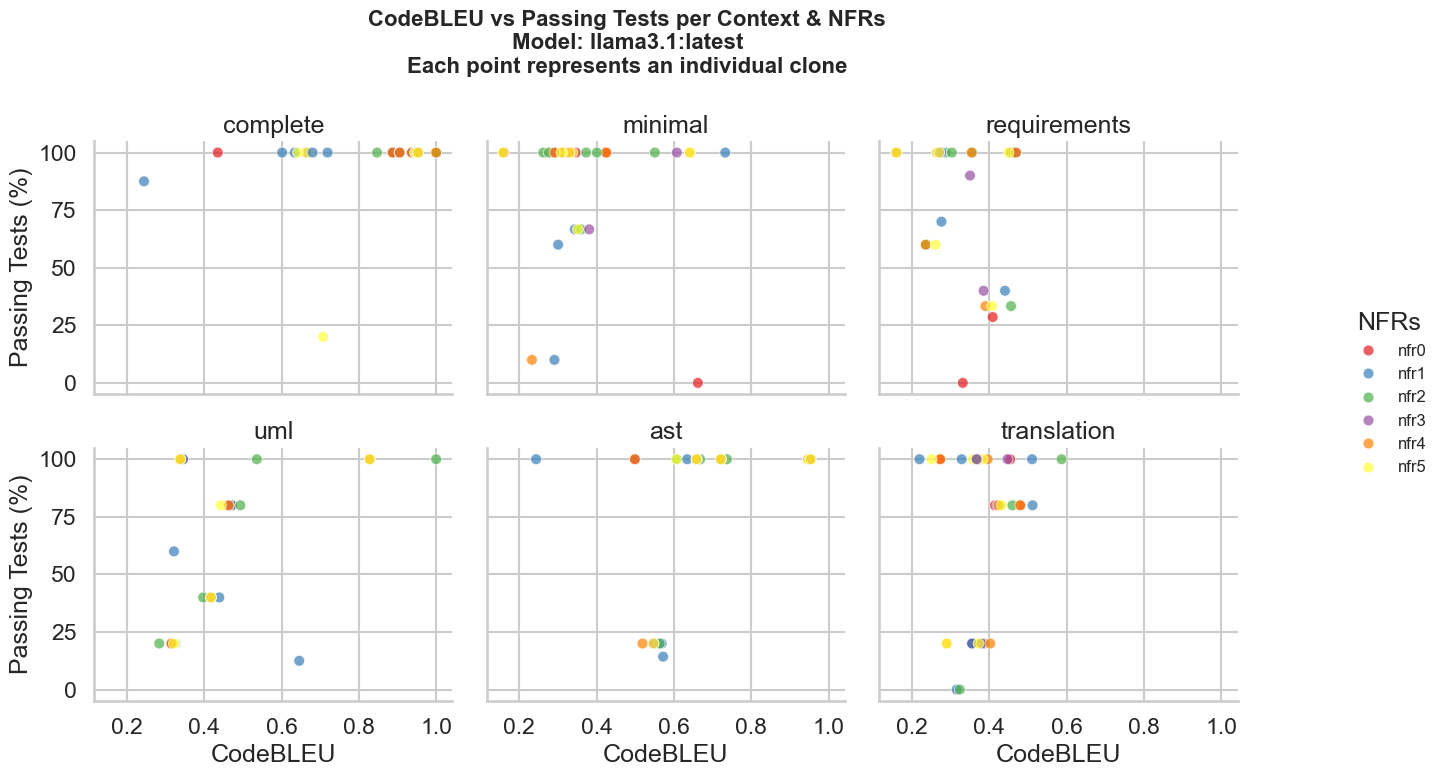

In [19]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load dataset ===
with open(OUT_PATH, "r", encoding="utf-8") as f:
    dataset = json.load(f)

# === Flatten data ===
records = []
for entry in dataset:
    for clone in entry.get("clones", []):
        model = clone.get("model", "unknown")
        results = clone.get("test_results", {})
        total_tests = len(results)
        if total_tests == 0:
            continue
        passed_tests = sum(1 for status in results.values() if status.upper() == "PASS")
        passing_percentage = 100 * passed_tests / total_tests
        score = clone.get("metrics", {}).get("codebleu", 0)

        context = clone.get("context", "unknown")
        nfrs = clone.get("nfrs", "unknown")
        records.append({
            "model": model,
            "context": context,
            "nfrs": nfrs,
            "codebleu": score,
            "passing": passing_percentage
        })

df = pd.DataFrame(records)

# === Plotting per model ===
sns.set_style("whitegrid")
sns.set_context("talk")

for model_name, model_df in df.groupby("model"):
    g = sns.FacetGrid(model_df, col="context", col_wrap=3, height=4, sharex=True, sharey=True)
    g.map_dataframe(
        sns.scatterplot,
        x="codebleu",
        y="passing",
        hue="nfrs",
        palette="Set1",
        alpha=0.7,
        s=60
    )

    # Axis labels and titles
    g.set_axis_labels("CodeBLEU", "Passing Tests (%)")
    g.set_titles(col_template="{col_name}")

    # Figure title
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(
        f"CodeBLEU vs Passing Tests per Context & NFRs\nModel: {model_name}\nEach point represents an individual clone",
        fontsize=16, weight="bold"
    )

    # Legend outside
    g.add_legend(title="NFRs", bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize=12, title_fontsize=13)

    plt.tight_layout()
    plt.show()
